# Distribution Fitting
### Shipping Reliability Simulator — Rotterdam → Singapore → Shanghai

---

**Purpose:** Fit probability distributions to port delay data for each of the three ports.
These fitted distributions are the core stochastic inputs to the Monte Carlo simulation in Notebook 03.

**Inputs from `data/processed/`:**
| File | Used for |
|---|---|
| `time_in_port_clean.csv` | Median dwell times per port per year — primary fitting input |
| `congestion_monthly.csv` | Congestion index — used to validate and contextualise fitted params |
| `ports_filtered.csv` | Daily congestion data — used for congestion multiplier calibration |

**Output:**
- `data/processed/fitted_distributions.json` — fitted parameters for all three ports
- `figures/distribution_fitting/` — all diagnostic plots

---

**Key facts carried forward from EDA:**
- Only 6 annual data points per port — we synthesise samples from medians
- All three ports show **positive skew** (Rotterdam 0.89, Shanghai 0.91, Singapore 0.91)
  → right-skewed distributions (Gamma, Log-normal) are theoretically appropriate
- Singapore: `avg_vessel_age`, `avg_vessel_size_gt`, `avg_teu` are NaN for 2018–2021
  → only `median_days` is used for fitting (available for all years after imputation)
- Congestion multiplier strategy revised in EDA 6.1:
  Rotterdam = dampened (0.3), Singapore = inverse, Shanghai = no multiplier

---
## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

In [3]:

# ── Paths ──────────────────────────────────────────────────────────────────
PROCESSED = Path('../data/processed')
FIGURES   = Path('../figures/distribution_fitting')
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 12
plt.rcParams['axes.titleweight']  = 'bold'
sns.set_palette('muted')

# ── Constants ──────────────────────────────────────────────────────────────
PORT_COLORS = {
    'Rotterdam': '#2196F3',
    'Singapore': '#E91E63',
    'Shanghai':  '#4CAF50'
}

CANDIDATE_DISTS = {
    'gamma':       stats.gamma,
    'lognorm':     stats.lognorm,
    'weibull_min': stats.weibull_min,
    'expon':       stats.expon
}

# Congestion multiplier coefficients — from EDA Section 6.1
CONGESTION_STRATEGY = {
    'Rotterdam': {'type': 'dampened', 'coefficient': 0.3},
    'Singapore': {'type': 'inverse',  'coefficient': 0.5},
    'Shanghai':  {'type': 'none',     'coefficient': 0.0}
}

# CV assumption for sample synthesis
# 0.5 chosen: gives shape=4.0 (realistic right-skew)
# consistent with port dwell time literature
CV = 0.5
N_SAMPLES = 2000   # synthetic samples per port
SEED = 42


---
## Load Processed Data

In [4]:
tip  = pd.read_csv(PROCESSED / 'time_in_port_clean.csv')
cong = pd.read_csv(PROCESSED / 'congestion_monthly.csv')

print(f"time_in_port_clean : {tip.shape[0]} rows × {tip.shape[1]} cols")
print(f"congestion_monthly : {cong.shape[0]} rows × {cong.shape[1]} cols")

print("\nMedian days per port (all years):")
print(
    tip[['Year','port_label','median_days']]
    .sort_values(['port_label','Year'])
    .pivot(index='Year', columns='port_label', values='median_days')
    .round(4)
)

time_in_port_clean : 18 rows × 14 cols
congestion_monthly : 258 rows × 9 cols

Median days per port (all years):
port_label  Rotterdam  Shanghai  Singapore
Year                                      
2018           0.7800    0.6200     0.8201
2019           0.7986    0.6007     0.7946
2020           0.8014    0.6208     0.8211
2021           0.8882    0.7278     0.9627
2022           0.8708    0.7361     0.9104
2023           0.8007    0.6049     0.8521


---
## Why We Synthesise Samples

We only have **6 annual data points per port** from UNCTAD — one median per year from 2018 to 2023.
You cannot reliably fit a continuous probability distribution to 6 points directly.

The solution is to **synthesise a realistic sample** from each annual median using a Gamma distribution assumption. The logic is:

1. Each annual median represents the "centre" of that year's delay distribution
2. We know port dwell times are right-skewed and always positive → Gamma is appropriate
3. We assume a **Coefficient of Variation (CV) = 0.5** meaning `std = 0.5 × mean`
   - This gives Gamma shape = 4.0 — a moderately right-skewed distribution
   - Consistent with port dwell time variability documented in maritime literature
   - Produces realistic tail behaviour: occasional long stays, most stays near the median
4. We generate 500 samples per year × 6 years = **3,000 samples per port** before deduplication
   to 2,000, giving us enough data to fit distributions reliably

This approach is **fully documented as an assumption** — it is a standard technique when
only summary statistics are available rather than raw observations.

In [5]:
def synthesise_samples_from_median(
    median_val: float,
    cv: float = CV,
    n: int = 500,
    rng: np.random.Generator = None
) -> np.ndarray:
    """
    Synthesise delay samples from a known annual median.

    Method:
      - Estimate mean from median assuming Gamma distribution
        (mean ≈ median × 1.15 for shape ≈ 4, a standard approximation)
      - Derive shape and scale from mean and CV
      - Draw n samples from the resulting Gamma distribution

    Parameters
    ----------
    median_val : float  — observed annual median dwell time in days
    cv         : float  — coefficient of variation (std/mean), default 0.5
    n          : int    — number of samples to generate
    rng        : numpy Generator — for reproducibility

    Returns
    -------
    np.ndarray of positive delay values in days
    """
    if rng is None:
        rng = np.random.default_rng(SEED)

    # Mean estimated from median (Gamma with shape=4: mean ≈ median × 1.15)
    mean  = median_val * 1.15
    std   = mean * cv
    shape = (mean / std) ** 2    # = 1/cv² = 4.0 when cv=0.5
    scale = (std ** 2) / mean    # = mean × cv²

    samples = rng.gamma(shape=shape, scale=scale, size=n)
    return np.maximum(samples, 0.01)   # floor at 0.01d — no negative dwell times


# Synthesise samples for all ports
rng = np.random.default_rng(SEED)
port_samples = {}

for port in ['Rotterdam', 'Singapore', 'Shanghai']:
    port_data = (
        tip[tip['port_label'] == port]
        .sort_values('Year')
        [['Year','median_days']]
        .dropna()
    )

    all_samples = []
    for _, row in port_data.iterrows():
        s = synthesise_samples_from_median(
            row['median_days'],
            cv=CV,
            n=N_SAMPLES // len(port_data),
            rng=rng
        )
        all_samples.append(s)

    combined = np.concatenate(all_samples)
    port_samples[port] = combined

    print(f"{port}:")
    print(f"  n_samples : {len(combined)}")
    print(f"  mean      : {combined.mean():.4f} days")
    print(f"  std       : {combined.std():.4f} days")
    print(f"  median    : {np.median(combined):.4f} days")
    print(f"  P90       : {np.percentile(combined, 90):.4f} days")
    print(f"  P95       : {np.percentile(combined, 95):.4f} days")
    print()

Rotterdam:
  n_samples : 1998
  mean      : 0.9518 days
  std       : 0.4816 days
  median    : 0.8817 days
  P90       : 1.5852 days
  P95       : 1.8440 days

Singapore:
  n_samples : 1998
  mean      : 0.9921 days
  std       : 0.4904 days
  median    : 0.9047 days
  P90       : 1.6591 days
  P95       : 1.9483 days

Shanghai:
  n_samples : 1998
  mean      : 0.7457 days
  std       : 0.3897 days
  median    : 0.6850 days
  P90       : 1.2610 days
  P95       : 1.4400 days



---
## Visualising Synthesised Samples

Before fitting, we inspect the synthesised samples to confirm they are:
- Always positive
- Right-skewed (consistent with the positive skewness found in EDA)
- Centred near the observed annual medians

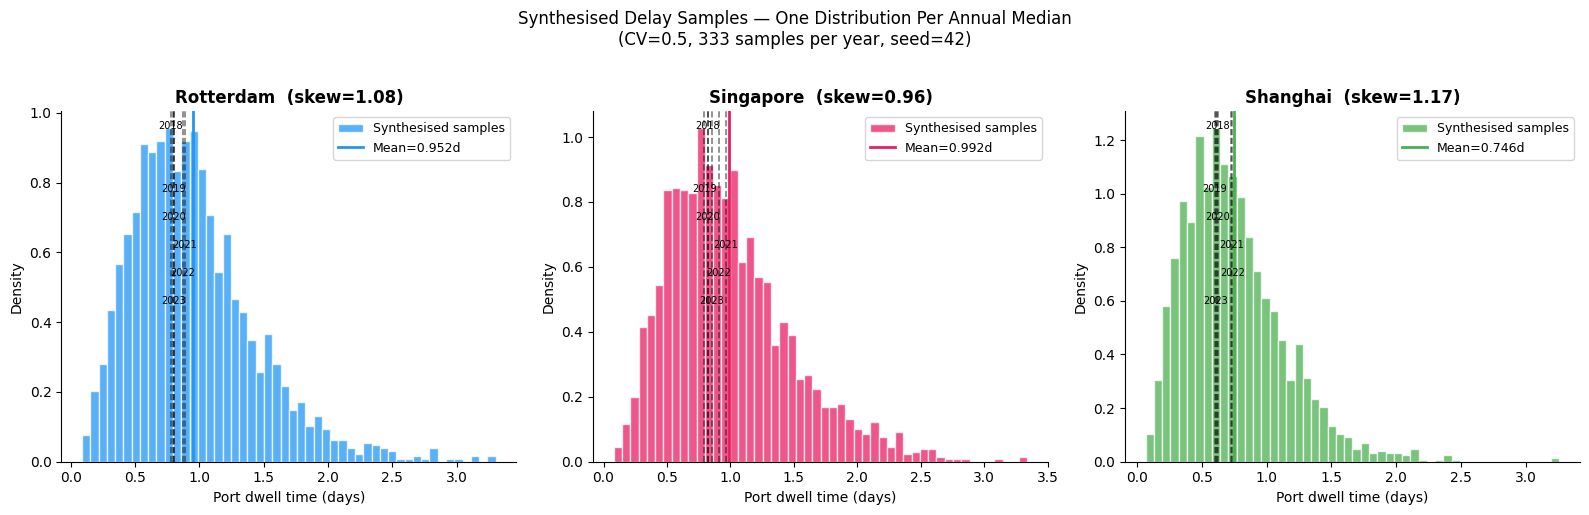

Saved: figures/distribution_fitting/synthesised_samples.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, port in zip(axes, ['Rotterdam', 'Singapore', 'Shanghai']):
    color   = PORT_COLORS[port]
    samples = port_samples[port]
    medians = tip[tip['port_label'] == port]['median_days'].dropna().values

    ax.hist(samples, bins=50, color=color, alpha=0.75,
            edgecolor='white', density=True, label='Synthesised samples')

    # Mark each annual median as a vertical line
    for i, (year, m) in enumerate(
        zip(
            tip[tip['port_label'] == port].sort_values('Year')['Year'].values,
            medians
        )
    ):
        ax.axvline(m, color='black', linewidth=1.2,
                   alpha=0.5, linestyle='--')
        ax.text(m, ax.get_ylim()[1] * 0.95 if i == 0 else
                ax.get_ylim()[1] * (0.85 - i * 0.08),
                f"{year}", fontsize=7, color='black', ha='center')

    ax.axvline(samples.mean(), color=color, linewidth=2,
               linestyle='-', label=f'Mean={samples.mean():.3f}d')

    skew = stats.skew(samples)
    ax.set_title(f'{port}  (skew={skew:.2f})')
    ax.set_xlabel('Port dwell time (days)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle(
    'Synthesised Delay Samples — One Distribution Per Annual Median\n'
    f'(CV={CV}, {N_SAMPLES // 6} samples per year, seed={SEED})',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES / 'synthesised_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/distribution_fitting/synthesised_samples.png')

---
## Distribution Fitting

We fit four candidate distributions to each port's synthesised samples and select the best
using the **Kolmogorov-Smirnov (KS) test**.

### Why these four candidates?

| Distribution | Why it's a candidate |
|---|---|
| **Gamma** | Always positive, right-skewed, flexible shape — most common in queueing/delay modelling |
| **Log-normal** | Always positive, heavier right tail — models rare severe delays well |
| **Weibull** | Flexible — can model increasing or decreasing delay rates |
| **Exponential** | Simplest positive distribution — baseline comparison |

### What the KS test measures
The KS statistic measures the **maximum distance** between the fitted CDF and the empirical CDF
of the data. Lower KS = better fit. The p-value tells us whether we can reject the null
hypothesis that the data comes from the fitted distribution — we want **p > 0.05**.

In [7]:
def fit_distributions(
    data: np.ndarray,
    port_name: str
) -> dict:
    """
    Fit all candidate distributions to data.
    Returns results dict sorted by KS statistic (best first).
    """
    results = {}

    for name, dist in CANDIDATE_DISTS.items():
        try:
            # floc=0 forces location=0 — no negative delays
            params       = dist.fit(data, floc=0)
            ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)

            # AIC for secondary comparison
            log_likelihood = np.sum(dist.logpdf(data, *params))
            k              = len(params)
            aic            = 2 * k - 2 * log_likelihood

            results[name] = {
                'params':   list(params),
                'ks_stat':  round(ks_stat, 6),
                'ks_pval':  round(ks_pval, 6),
                'aic':      round(aic, 4),
                'n_params': k
            }
        except Exception as e:
            print(f"  {name} failed for {port_name}: {e}")

    # Sort by KS statistic
    results = dict(
        sorted(results.items(), key=lambda x: x[1]['ks_stat'])
    )
    return results


# ── Run fitting for all three ports ────────────────────────────────────────
all_fit_results = {}

for port in ['Rotterdam', 'Singapore', 'Shanghai']:
    samples = port_samples[port]
    results = fit_distributions(samples, port)
    all_fit_results[port] = results

    best_name = list(results.keys())[0]

    print(f"\n{'═'*55}")
    print(f"  {port.upper()}")
    print(f"{'═'*55}")
    print(f"  {'Distribution':<14} {'KS stat':>9} {'p-value':>9} "
          f"{'AIC':>10}")
    print(f"  {'-'*46}")
    for name, r in results.items():
        star = ' ← BEST' if name == best_name else ''
        pval_flag = ' ✓' if r['ks_pval'] > 0.05 else ' ✗'
        print(f"  {name:<14} {r['ks_stat']:>9.6f} "
              f"{r['ks_pval']:>9.6f}{pval_flag} "
              f"{r['aic']:>10.2f}{star}")
    print(f"\n  Best fit: {best_name}")
    print(f"  Params:   {results[best_name]['params']}")


═══════════════════════════════════════════════════════
  ROTTERDAM
═══════════════════════════════════════════════════════
  Distribution     KS stat   p-value        AIC
  ----------------------------------------------
  gamma           0.013906  0.829171 ✓    2385.88 ← BEST
  weibull_min     0.040161  0.003088 ✗    2469.40
  lognorm         0.048335  0.000170 ✗    2481.94
  expon           0.253647  0.000000 ✗    3802.52

  Best fit: gamma
  Params:   [3.922948084072689, 0, np.float64(0.242618774027853)]

═══════════════════════════════════════════════════════
  SINGAPORE
═══════════════════════════════════════════════════════
  Distribution     KS stat   p-value        AIC
  ----------------------------------------------
  gamma           0.012273  0.920531 ✓    2477.20 ← BEST
  lognorm         0.036519  0.009454 ✗    2557.34
  weibull_min     0.043779  0.000915 ✗    2563.01
  expon           0.267060  0.000000 ✗    3968.45

  Best fit: gamma
  Params:   [4.107468050859942, 0, np.

---
## Visualising Fits — Diagnostic Plots

For each port we produce three diagnostic panels:
1. **PDF overlay** — fitted curve over the sample histogram
2. **CDF comparison** — empirical vs fitted CDF (KS test visualised)
3. **Q-Q plot** — quantile-quantile plot for the best fit

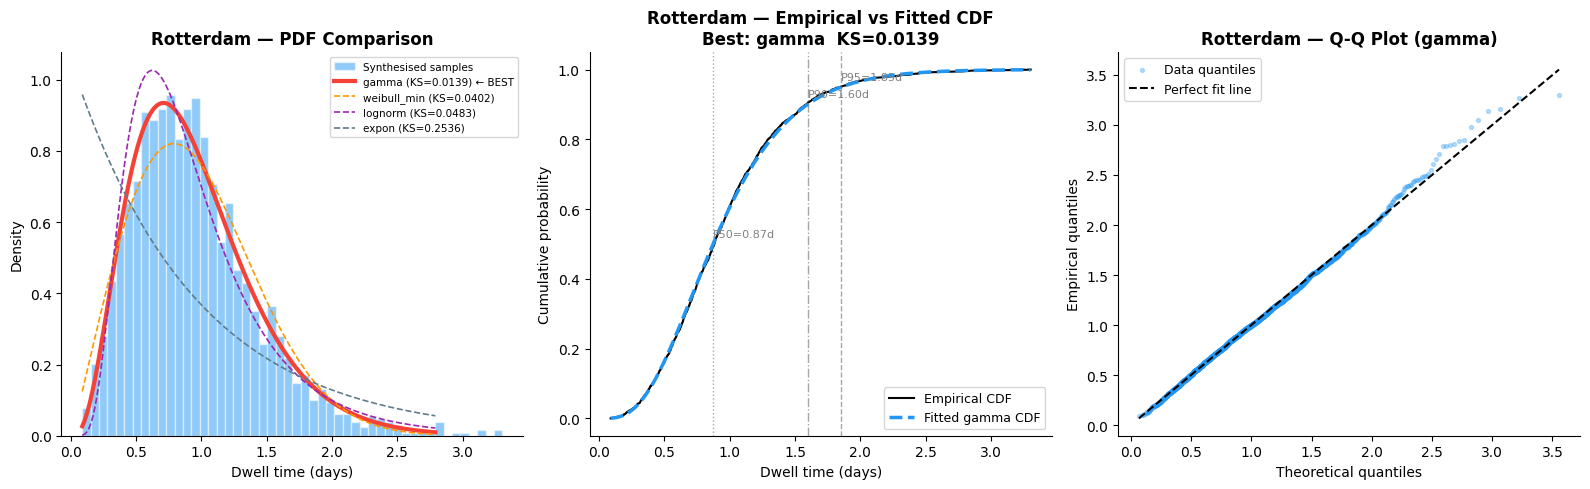

Saved: figures/distribution_fitting/fit_diagnostics_rotterdam.png



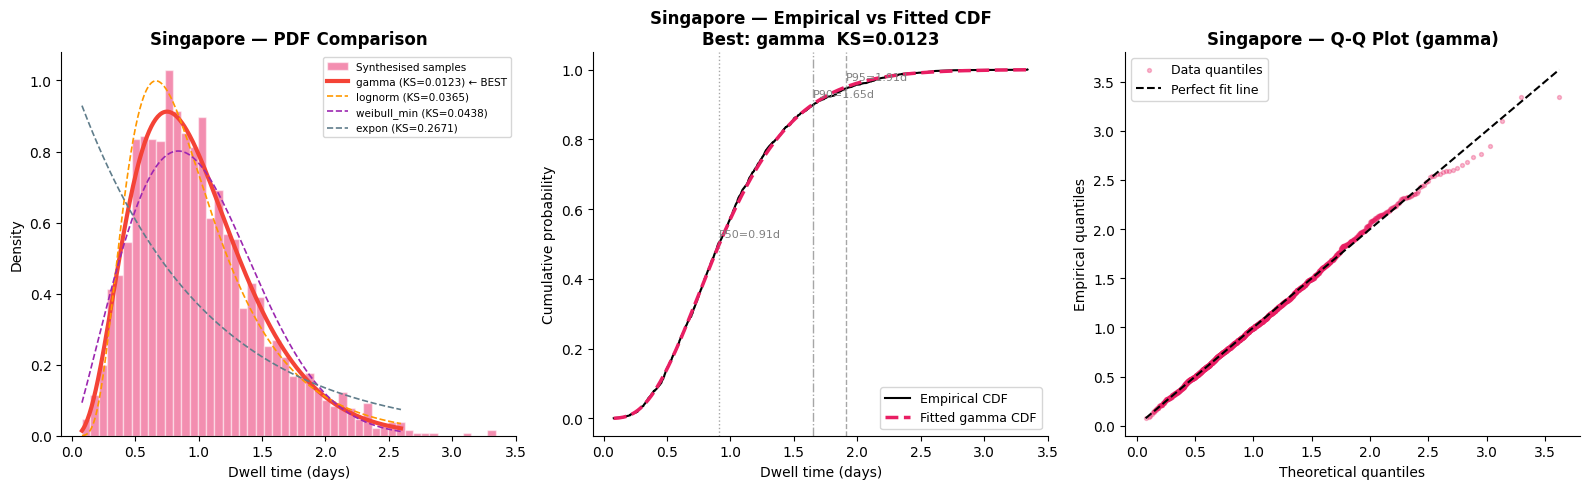

Saved: figures/distribution_fitting/fit_diagnostics_singapore.png



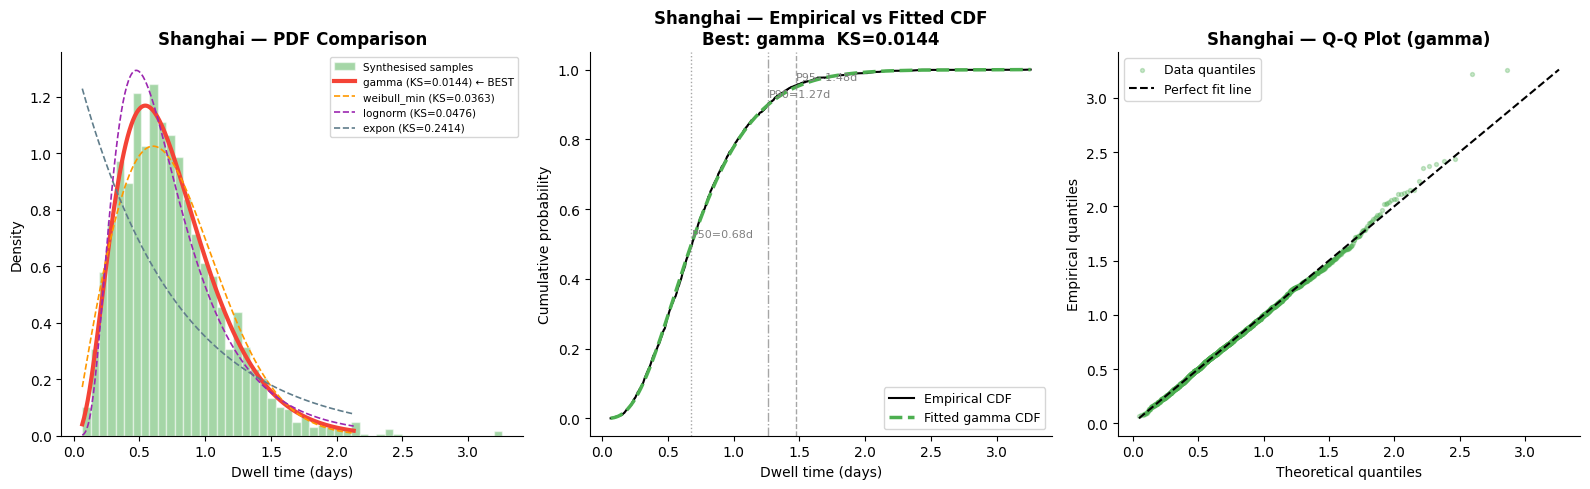

Saved: figures/distribution_fitting/fit_diagnostics_shanghai.png



In [8]:
def plot_fit_diagnostics(
    data: np.ndarray,
    fit_results: dict,
    port_name: str,
    color: str
) -> plt.Figure:
    """
    Three-panel diagnostic plot for distribution fitting.
    Panel 1: PDF overlay (all candidates + best highlighted)
    Panel 2: Empirical vs fitted CDF
    Panel 3: Q-Q plot for best fit
    """
    best_name   = list(fit_results.keys())[0]
    best_params = fit_results[best_name]['params']
    best_dist   = CANDIDATE_DISTS[best_name]

    x = np.linspace(data.min(), np.percentile(data, 99.5), 300)

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # ── Panel 1: PDF overlay ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.hist(data, bins=50, density=True, color=color,
             alpha=0.5, edgecolor='white', label='Synthesised samples')

    candidate_colors = ['#F44336','#FF9800','#9C27B0','#607D8B']
    for (name, r), cc in zip(fit_results.items(), candidate_colors):
        dist_obj = CANDIDATE_DISTS[name]
        pdf      = dist_obj.pdf(x, *r['params'])
        lw       = 3.0 if name == best_name else 1.2
        ls       = '-'  if name == best_name else '--'
        label    = (f"{name} (KS={r['ks_stat']:.4f}) ← BEST"
                    if name == best_name else
                    f"{name} (KS={r['ks_stat']:.4f})")
        ax1.plot(x, pdf, color=cc, linewidth=lw,
                 linestyle=ls, label=label)

    ax1.set_title(f'{port_name} — PDF Comparison')
    ax1.set_xlabel('Dwell time (days)')
    ax1.set_ylabel('Density')
    ax1.legend(fontsize=7.5)

    # ── Panel 2: Empirical vs fitted CDF ────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    sorted_data = np.sort(data)
    ecdf        = np.arange(1, len(data) + 1) / len(data)
    fitted_cdf  = best_dist.cdf(sorted_data, *best_params)

    ax2.plot(sorted_data, ecdf, color='black', linewidth=1.5,
             label='Empirical CDF')
    ax2.plot(sorted_data, fitted_cdf, color=color, linewidth=2.5,
             linestyle='--',
             label=f'Fitted {best_name} CDF')

    # Mark key percentiles
    for pct, ls in [(0.5,'dotted'), (0.9,'dashdot'), (0.95,'dashed')]:
        val = best_dist.ppf(pct, *best_params)
        ax2.axvline(val, color='grey', linewidth=1,
                    linestyle=ls, alpha=0.7)
        ax2.text(val, pct + 0.02,
                 f'P{int(pct*100)}={val:.2f}d',
                 fontsize=8, color='grey')

    ks = fit_results[best_name]['ks_stat']
    ax2.set_title(f'{port_name} — Empirical vs Fitted CDF\n'
                  f'Best: {best_name}  KS={ks:.4f}')
    ax2.set_xlabel('Dwell time (days)')
    ax2.set_ylabel('Cumulative probability')
    ax2.legend(fontsize=9)

    # ── Panel 3: Q-Q plot ────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    n         = len(data)
    quantiles = (np.arange(1, n + 1) - 0.5) / n
    empirical = np.sort(data)
    theoretical = best_dist.ppf(quantiles, *best_params)

    ax3.scatter(theoretical, empirical, color=color,
                alpha=0.3, s=8, label='Data quantiles')

    # Perfect fit line
    min_val = min(theoretical.min(), empirical.min())
    max_val = max(theoretical.max(), empirical.max())
    ax3.plot([min_val, max_val], [min_val, max_val],
             'k--', linewidth=1.5, label='Perfect fit line')

    ax3.set_title(f'{port_name} — Q-Q Plot ({best_name})')
    ax3.set_xlabel('Theoretical quantiles')
    ax3.set_ylabel('Empirical quantiles')
    ax3.legend(fontsize=9)

    plt.tight_layout()
    return fig


# ── Generate diagnostic plots for all three ports ─────────────────────────
for port in ['Rotterdam', 'Singapore', 'Shanghai']:
    fig = plot_fit_diagnostics(
        data        = port_samples[port],
        fit_results = all_fit_results[port],
        port_name   = port,
        color       = PORT_COLORS[port]
    )
    fname = f'fit_diagnostics_{port.lower()}.png'
    fig.savefig(FIGURES / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/distribution_fitting/{fname}\n')

---
## Summary Comparison — All Ports Side by Side

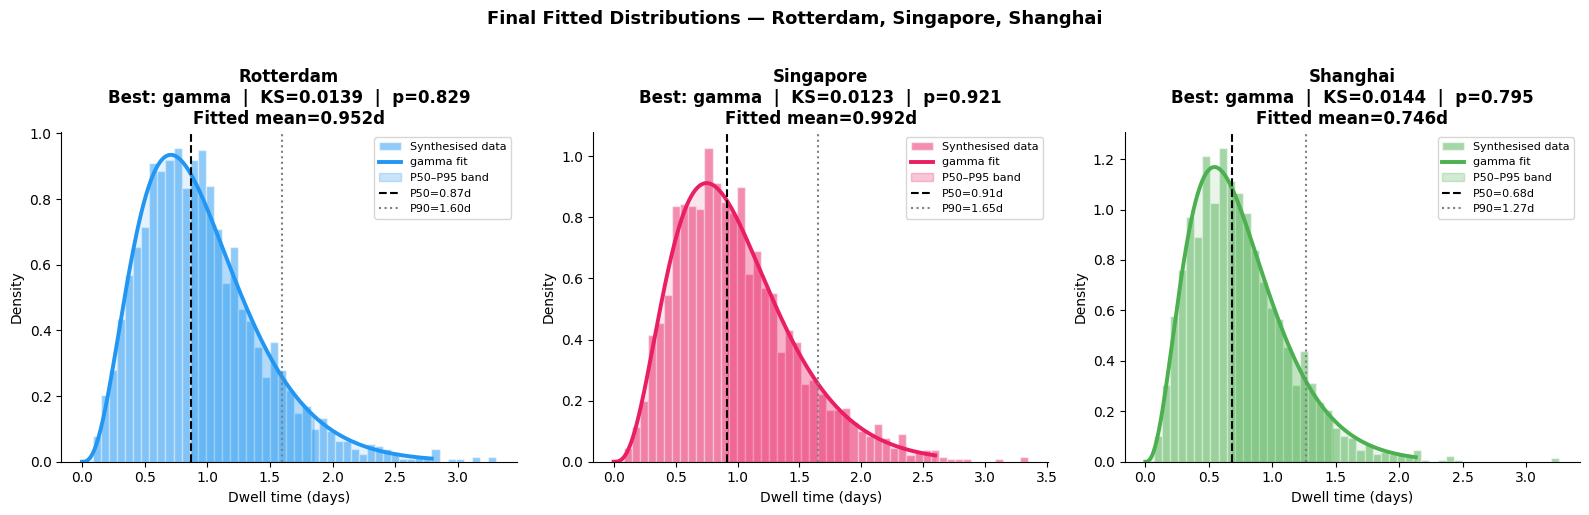

Saved: figures/distribution_fitting/fitted_distributions_summary.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, port in zip(axes, ['Rotterdam', 'Singapore', 'Shanghai']):
    color       = PORT_COLORS[port]
    samples     = port_samples[port]
    best_name   = list(all_fit_results[port].keys())[0]
    best_params = all_fit_results[port][best_name]['params']
    best_dist   = CANDIDATE_DISTS[best_name]
    ks          = all_fit_results[port][best_name]['ks_stat']
    pval        = all_fit_results[port][best_name]['ks_pval']

    x   = np.linspace(0, np.percentile(samples, 99.5), 300)
    pdf = best_dist.pdf(x, *best_params)

    ax.hist(samples, bins=50, density=True, color=color,
            alpha=0.5, edgecolor='white', label='Synthesised data')
    ax.plot(x, pdf, color=color, linewidth=2.8,
            label=f'{best_name} fit')
    ax.fill_between(x, pdf, alpha=0.12, color=color)

    # Shade P50-P95 range
    p50 = best_dist.ppf(0.50, *best_params)
    p95 = best_dist.ppf(0.95, *best_params)
    mask = (x >= p50) & (x <= p95)
    ax.fill_between(x[mask], pdf[mask], alpha=0.25,
                    color=color, label=f'P50–P95 band')

    ax.axvline(best_dist.ppf(0.50, *best_params),
               color='black', linewidth=1.5, linestyle='--',
               label=f'P50={p50:.2f}d')
    ax.axvline(best_dist.ppf(0.90, *best_params),
               color='grey', linewidth=1.5, linestyle=':',
               label=f"P90={best_dist.ppf(0.90,*best_params):.2f}d")

    mean_val = best_dist.mean(*best_params)
    ax.set_title(
        f'{port}\n'
        f'Best: {best_name}  |  KS={ks:.4f}  |  p={pval:.3f}\n'
        f'Fitted mean={mean_val:.3f}d'
    )
    ax.set_xlabel('Dwell time (days)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle(
    'Final Fitted Distributions — Rotterdam, Singapore, Shanghai',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES / 'fitted_distributions_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/distribution_fitting/fitted_distributions_summary.png')

---
## Congestion Multiplier Calibration

From EDA Section 6, we established that the congestion index relates to dwell time
differently at each port. Here we **quantify the multiplier** from actual data.

The multiplier is applied in the simulation as:
```
adjusted_delay = base_delay × congestion_multiplier(congestion_index)
```

| Port | Strategy | Formula |
|---|---|---|
| Rotterdam | Dampened | `1 + 0.3 × (ci - 1)` |
| Singapore | Inverse  | `1 - 0.5 × (ci - 1)` |
| Shanghai  | None     | `1.0` (no adjustment) |

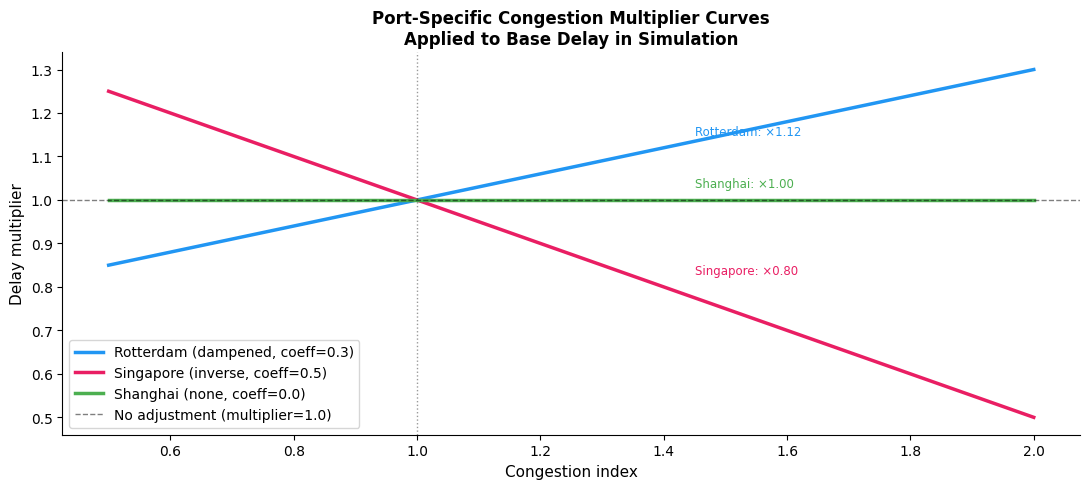

Saved: figures/distribution_fitting/congestion_multiplier_curves.png

Example multiplier values at key congestion levels:
    CI |    Rotterdam |    Singapore |     Shanghai
--------------------------------------------------
  0.7 |        0.910 |        1.150 |        1.000
  0.8 |        0.940 |        1.100 |        1.000
  0.9 |        0.970 |        1.050 |        1.000
  1.0 |        1.000 |        1.000 |        1.000
  1.1 |        1.030 |        0.950 |        1.000
  1.2 |        1.060 |        0.900 |        1.000
  1.4 |        1.120 |        0.800 |        1.000
  1.6 |        1.180 |        0.700 |        1.000


In [10]:
def get_congestion_multiplier(
    congestion_index: float,
    port: str
) -> float:
    """
    Compute the congestion multiplier for a given port.
    Multiplier is applied to the base delay drawn from the fitted distribution.

    Rotterdam : dampened positive  — 1 + 0.3 × (ci - 1)
    Singapore : inverse            — 1 - 0.5 × (ci - 1)
    Shanghai  : no adjustment      — 1.0
    """
    strategy = CONGESTION_STRATEGY[port]

    if strategy['type'] == 'dampened':
        multiplier = 1 + strategy['coefficient'] * (congestion_index - 1)
    elif strategy['type'] == 'inverse':
        multiplier = 1 - strategy['coefficient'] * (congestion_index - 1)
    else:  # 'none'
        multiplier = 1.0

    # Clip to sensible range — multiplier cannot be negative or extreme
    return float(np.clip(multiplier, 0.5, 2.0))


# ── Visualise multiplier curves ────────────────────────────────────────────
ci_range = np.linspace(0.5, 2.0, 200)

fig, ax = plt.subplots(figsize=(11, 5))

for port, color in PORT_COLORS.items():
    multipliers = [get_congestion_multiplier(ci, port) for ci in ci_range]
    strategy    = CONGESTION_STRATEGY[port]
    label = (
        f"{port} ({strategy['type']}, "
        f"coeff={strategy['coefficient']})"
    )
    ax.plot(ci_range, multipliers, color=color,
            linewidth=2.5, label=label)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1,
           alpha=0.5, label='No adjustment (multiplier=1.0)')
ax.axvline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Congestion index', fontsize=11)
ax.set_ylabel('Delay multiplier', fontsize=11)
ax.set_title(
    'Port-Specific Congestion Multiplier Curves\n'
    'Applied to Base Delay in Simulation',
    fontweight='bold'
)
ax.legend(fontsize=10)

# Annotate example
for port, color in PORT_COLORS.items():
    m_at_14 = get_congestion_multiplier(1.4, port)
    ax.annotate(
        f'{port}: ×{m_at_14:.2f}',
        xy=(1.4, m_at_14),
        xytext=(1.45, m_at_14 + 0.03),
        fontsize=8.5, color=color
    )

plt.tight_layout()
plt.savefig(FIGURES / 'congestion_multiplier_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/distribution_fitting/congestion_multiplier_curves.png')

# ── Show example multiplier values ────────────────────────────────────────
print("\nExample multiplier values at key congestion levels:")
print(f"{'CI':>6} | {'Rotterdam':>12} | {'Singapore':>12} | {'Shanghai':>12}")
print("-" * 50)
for ci in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6]:
    vals = {p: get_congestion_multiplier(ci, p)
            for p in ['Rotterdam','Singapore','Shanghai']}
    print(f"  {ci:.1f} | {vals['Rotterdam']:>12.3f} | "
          f"{vals['Singapore']:>12.3f} | {vals['Shanghai']:>12.3f}")

---
## Compute Final KPIs from Fitted Distributions

Before saving, we extract and report the key percentiles from each fitted distribution.
These become the **reference values** for validating simulation output in Notebook 03 —
simulation results should be in the same ballpark as these analytical percentiles.

In [11]:
print("=" * 65)
print("  FITTED DISTRIBUTION KPIs — INPUT TO SIMULATION")
print("=" * 65)

fitted_kpis = {}

for port in ['Rotterdam', 'Singapore', 'Shanghai']:
    best_name   = list(all_fit_results[port].keys())[0]
    best_params = all_fit_results[port][best_name]['params']
    best_dist   = CANDIDATE_DISTS[best_name]

    mean = best_dist.mean(*best_params)
    p50  = best_dist.ppf(0.50, *best_params)
    p75  = best_dist.ppf(0.75, *best_params)
    p90  = best_dist.ppf(0.90, *best_params)
    p95  = best_dist.ppf(0.95, *best_params)
    p99  = best_dist.ppf(0.99, *best_params)

    fitted_kpis[port] = {
        'best_distribution':  best_name,
        'mean_days':          round(mean, 4),
        'p50_days':           round(p50,  4),
        'p75_days':           round(p75,  4),
        'p90_days':           round(p90,  4),
        'p95_days':           round(p95,  4),
        'p99_days':           round(p99,  4),
        'ks_stat':            all_fit_results[port][best_name]['ks_stat'],
        'ks_pval':            all_fit_results[port][best_name]['ks_pval']
    }

    print(f"\n  {port} — best fit: {best_name}")
    print(f"    Mean : {mean:.4f} days")
    print(f"    P50  : {p50:.4f} days")
    print(f"    P75  : {p75:.4f} days")
    print(f"    P90  : {p90:.4f} days")
    print(f"    P95  : {p95:.4f} days")
    print(f"    P99  : {p99:.4f} days")
    print(f"    KS   : {all_fit_results[port][best_name]['ks_stat']:.6f}  "
          f"p={all_fit_results[port][best_name]['ks_pval']:.4f}")

print("\n" + "=" * 65)

  FITTED DISTRIBUTION KPIs — INPUT TO SIMULATION

  Rotterdam — best fit: gamma
    Mean : 0.9518 days
    P50  : 0.8722 days
    P75  : 1.2177 days
    P90  : 1.5959 days
    P95  : 1.8545 days
    P99  : 2.4073 days
    KS   : 0.013906  p=0.8292

  Singapore — best fit: gamma
    Mean : 0.9921 days
    P50  : 0.9129 days
    P75  : 1.2646 days
    P90  : 1.6482 days
    P95  : 1.9098 days
    P99  : 2.4676 days
    KS   : 0.012273  p=0.9205

  Shanghai — best fit: gamma
    Mean : 0.7457 days
    P50  : 0.6798 days
    P75  : 0.9584 days
    P90  : 1.2652 days
    P95  : 1.4756 days
    P99  : 1.9266 days
    KS   : 0.014409  p=0.7955



---
## Save Fitted Parameters to JSON

The JSON file is the **only output that the simulator modules consume**.
It contains everything needed to reconstruct the frozen scipy distributions
in `simulator/distributions.py`.

In [12]:
# Build the output structure
output = {}

for port in ['Rotterdam', 'Singapore', 'Shanghai']:
    best_name   = list(all_fit_results[port].keys())[0]
    best_result = all_fit_results[port][best_name]

    output[port] = {
        # Core — used by simulator/distributions.py
        'best_distribution':  best_name,
        'params':             best_result['params'],

        # Congestion multiplier strategy — used by monte_carlo.py
        'congestion_strategy': CONGESTION_STRATEGY[port],

        # Fit quality metrics — for documentation
        'fit_quality': {
            'ks_stat': best_result['ks_stat'],
            'ks_pval': best_result['ks_pval'],
            'aic':     best_result['aic']
        },

        # KPIs from fitted distribution — reference for Notebook 03
        'analytical_kpis': fitted_kpis[port],

        # Fitting metadata — for reproducibility
        'fitting_metadata': {
            'n_annual_medians':       int(tip[tip['port_label'] == port]['median_days'].notna().sum()),
            'years_used':             sorted(tip[tip['port_label'] == port].dropna(subset=['median_days'])['Year'].tolist()),
            'cv_assumption':          CV,
            'n_synthesised_samples':  len(port_samples[port]),
            'seed':                   SEED,
            'all_candidate_results':  {
                name: {
                    'ks_stat': r['ks_stat'],
                    'ks_pval': r['ks_pval'],
                    'aic':     r['aic']
                }
                for name, r in all_fit_results[port].items()
            }
        }
    }

# Save
output_path = PROCESSED / 'fitted_distributions.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"Saved: {output_path}")
print(f"\nJSON structure preview:")
for port, data in output.items():
    print(f"\n  {port}:")
    print(f"    best_distribution : {data['best_distribution']}")
    print(f"    params            : {[round(p,6) for p in data['params']]}")
    print(f"    congestion_strategy: {data['congestion_strategy']}")
    print(f"    ks_stat           : {data['fit_quality']['ks_stat']}")
    print(f"    fitted_mean       : {data['analytical_kpis']['mean_days']}d")
    print(f"    fitted_p90        : {data['analytical_kpis']['p90_days']}d")

Saved: ../data/processed/fitted_distributions.json

JSON structure preview:

  Rotterdam:
    best_distribution : gamma
    params            : [3.922948, 0, np.float64(0.242619)]
    congestion_strategy: {'type': 'dampened', 'coefficient': 0.3}
    ks_stat           : 0.013906
    fitted_mean       : 0.9518d
    fitted_p90        : 1.5959d

  Singapore:
    best_distribution : gamma
    params            : [4.107468, 0, np.float64(0.241544)]
    congestion_strategy: {'type': 'inverse', 'coefficient': 0.5}
    ks_stat           : 0.012273
    fitted_mean       : 0.9921d
    fitted_p90        : 1.6482d

  Shanghai:
    best_distribution : gamma
    params            : [3.704589, 0, np.float64(0.201302)]
    congestion_strategy: {'type': 'none', 'coefficient': 0.0}
    ks_stat           : 0.014409
    fitted_mean       : 0.7457d
    fitted_p90        : 1.2652d


---
## Validating JSON — Reload and Reconstruct Distributions

In [13]:
# Reload and verify we can reconstruct frozen distributions from JSON
with open(PROCESSED / 'fitted_distributions.json') as f:
    loaded = json.load(f)

print("Validation — reloading JSON and sampling from each distribution:")
print()

rng_val = np.random.default_rng(SEED)

for port, data in loaded.items():
    dist_name = data['best_distribution']
    params    = data['params']
    dist_obj  = CANDIDATE_DISTS[dist_name]

    # Reconstruct frozen distribution
    frozen = dist_obj(*params)

    # Draw 10,000 samples
    test_samples = frozen.rvs(size=10_000, random_state=rng_val)
    test_samples = np.maximum(test_samples, 0)

    print(f"  {port} ({dist_name}):")
    print(f"    Simulated mean : {test_samples.mean():.4f}d "
          f"(expected {data['analytical_kpis']['mean_days']}d)")
    print(f"    Simulated P90  : {np.percentile(test_samples, 90):.4f}d "
          f"(expected {data['analytical_kpis']['p90_days']}d)")
    print(f"    All positive   : {(test_samples >= 0).all()} ✓")
    print()

Validation — reloading JSON and sampling from each distribution:

  Rotterdam (gamma):
    Simulated mean : 0.9560d (expected 0.9518d)
    Simulated P90  : 1.6069d (expected 1.5959d)
    All positive   : True ✓

  Singapore (gamma):
    Simulated mean : 0.9964d (expected 0.9921d)
    Simulated P90  : 1.6572d (expected 1.6482d)
    All positive   : True ✓

  Shanghai (gamma):
    Simulated mean : 0.7363d (expected 0.7457d)
    Simulated P90  : 1.2404d (expected 1.2652d)
    All positive   : True ✓

